# 02 — Coeficientes obrigatórios para folhas de lag

## Resumo

Este experimento implementa e avalia a transformação recomendada para o gerador recorrente:

```text
LAG(j, l)  ->  MULTIPLY(P, LAG(j, l))
```

Cada dependência temporal passa a possuir um parâmetro explícito, amostrado com sinal aleatório e módulo entre 0,05 e 0,80. O comportamento anterior continua disponível com `coefficient_gate_lags=False`; a nova estratégia é ativada por `coefficient_gate_lags=True`.

A avaliação é pareada: para cada índice e semente, a variante baseline e a variante gated compartilham a árvore-base, os valores dos lags, as condições iniciais e as inovações. Assim, a diferença observada é atribuível à inserção dos coeficientes, embora cada coeficiente também altere a dinâmica numérica da fórmula.

## 1. Configuração

Os critérios reproduzem o Notebook 4: 5.000 mecanismos, horizontes 96, 192 e 384, cinco amplitudes iniciais, inovação normal com desvio 0,05, explosão acima de 100 e cauda próxima de zero dentro de ±0,15 nos 24 passos finais.

In [1]:
from __future__ import annotations

from dataclasses import asdict, replace
from pathlib import Path
import importlib.metadata
import json
import platform
import subprocess
import sys
import time

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "tsfmxai").exists():
            return candidate
    raise RuntimeError("Repository root not found.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SOURCE_ROOT = PROJECT_ROOT / "src"
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

from tsfmxai.generators import (
    RandomTreeConfig,
    evaluate_bound_expression,
    required_history_length,
    sample_random_mechanisms,
)
from tsfmxai.representations import Add, Lag, Multiply, Parameter, operator_count, walk

ROOT_SEED = 20261001
SAMPLE_COUNT = 5_000
HORIZONS = (96, 192, 384)
REFERENCE_HORIZON = 192
INNOVATION_STD = 0.05
INPUT_ABS_LIMITS = (0.0, 0.1, 0.5, 1.0, 2.0)
EXPLOSION_LIMIT = 100.0
NEAR_ZERO_RADIUS = 3.0 * INNOVATION_STD
NEAR_ZERO_TAIL_STEPS = 24

BASE_CONFIG = RandomTreeConfig(
    minimum_operators=1,
    maximum_operators=6,
    num_series=1,
    minimum_lag=1,
    maximum_lag=12,
    parameter_probability=0.55,
    time_probability=0.0,
    lag_probability=0.45,
    add_probability=0.80,
    minimum_parameter_magnitude=0.05,
    maximum_parameter_magnitude=0.80,
    require_lag=True,
    require_time=False,
    coefficient_gate_lags=False,
)
GATED_CONFIG = replace(BASE_CONFIG, coefficient_gate_lags=True)

configuration = {
    "root_seed": ROOT_SEED,
    "sample_count_per_variant": SAMPLE_COUNT,
    "horizons": list(HORIZONS),
    "reference_horizon": REFERENCE_HORIZON,
    "innovation_std": INNOVATION_STD,
    "input_absolute_limits": list(INPUT_ABS_LIMITS),
    "explosion_limit": EXPLOSION_LIMIT,
    "near_zero_radius": NEAR_ZERO_RADIUS,
    "near_zero_tail_steps": NEAR_ZERO_TAIL_STEPS,
    "baseline_tree_config": asdict(BASE_CONFIG),
    "gated_tree_config": asdict(GATED_CONFIG),
}
print(json.dumps(configuration, indent=2))

{
  "root_seed": 20261001,
  "sample_count_per_variant": 5000,
  "horizons": [
    96,
    192,
    384
  ],
  "reference_horizon": 192,
  "innovation_std": 0.05,
  "input_absolute_limits": [
    0.0,
    0.1,
    0.5,
    1.0,
    2.0
  ],
  "explosion_limit": 100.0,
  "near_zero_radius": 0.15000000000000002,
  "near_zero_tail_steps": 24,
  "baseline_tree_config": {
    "minimum_operators": 1,
    "maximum_operators": 6,
    "num_series": 1,
    "minimum_lag": 1,
    "maximum_lag": 12,
    "parameter_probability": 0.55,
    "time_probability": 0.0,
    "lag_probability": 0.45,
    "add_probability": 0.8,
    "minimum_parameter_magnitude": 0.05,
    "maximum_parameter_magnitude": 0.8,
    "require_lag": true,
    "require_time": false,
    "coefficient_gate_lags": false
  },
  "gated_tree_config": {
    "minimum_operators": 1,
    "maximum_operators": 6,
    "num_series": 1,
    "minimum_lag": 1,
    "maximum_lag": 12,
    "parameter_probability": 0.55,
    "time_probability": 0.0,
   

**O que foi feito.** As duas configurações diferem somente no campo `coefficient_gate_lags`. As sementes são locais e derivadas de índices estáveis.

## 2. Pares de mecanismos antes e depois da transformação

A implementação amostra a árvore e seus bindings como antes. Quando a opção está ativa, cada lag é envolvido por um novo `Multiply` e um novo `Parameter`; depois a expressão é recanonicalizada e os slots são relabelados.

In [2]:
sampling_times = {}
mechanisms_by_variant = {}
for variant, tree_config in (("baseline", BASE_CONFIG), ("coefficient-gated", GATED_CONFIG)):
    started = time.perf_counter()
    mechanisms_by_variant[variant] = sample_random_mechanisms(
        tree_config,
        root_seed=ROOT_SEED,
        count=SAMPLE_COUNT,
    )
    sampling_times[variant] = time.perf_counter() - started

baseline_mechanisms = mechanisms_by_variant["baseline"]
gated_mechanisms = mechanisms_by_variant["coefficient-gated"]


def lag_count(mechanism) -> int:
    return sum(isinstance(node, Lag) for node in walk(mechanism.expression))


def all_lags_have_direct_parameter_gate(expression) -> bool:
    if not isinstance(expression, (Add, Multiply)):
        return not isinstance(expression, Lag)
    valid = True
    for child, sibling in ((expression.left, expression.right), (expression.right, expression.left)):
        if isinstance(child, Lag):
            valid = valid and isinstance(expression, Multiply) and isinstance(sibling, Parameter)
        else:
            valid = valid and all_lags_have_direct_parameter_gate(child)
    return valid


for baseline, gated in zip(baseline_mechanisms, gated_mechanisms):
    assert baseline.sample_index == gated.sample_index
    assert baseline.seed == gated.seed
    assert lag_count(baseline) == lag_count(gated)
    assert sorted(baseline.binding.lag_values.values()) == sorted(gated.binding.lag_values.values())
    assert operator_count(gated.expression) == operator_count(baseline.expression) + lag_count(baseline)
    assert all_lags_have_direct_parameter_gate(gated.expression)

example_indices = [0, 1, 2, 3, 4]
examples = pd.DataFrame([
    {
        "sample_index": index,
        "lag_count": lag_count(baseline_mechanisms[index]),
        "baseline_formula": baseline_mechanisms[index].formula,
        "gated_formula": gated_mechanisms[index].formula,
    }
    for index in example_indices
])
display(examples)
print("Sampling times:", sampling_times)

,sample_index,lag_count,baseline_formula,gated_formula
0,0,1,(((-0.727339 + 0.163988) + -0.752925) + x_0(t-7)),(((-0.727339 + 0.163988) + -0.752925) + (x_0(t...
1,1,2,(((x_0(t-2) + -0.676288) + -0.610715) + x_0(t-...,((((x_0(t-2) * -0.198725) + -0.676288) + -0.61...
2,2,2,(((x_0(t-10) + 0.0941167) + -0.285746) * (x_0(...,((((x_0(t-10) * 0.603961) + 0.0941167) + -0.28...
3,3,3,(x_0(t-2) * ((((0.195079 + 0.168366) + -0.5606...,(((((0.195079 + 0.168366) + -0.560617) + (x_0(...
4,4,4,(((x_0(t-11) + x_0(t-11)) + (x_0(t-3) + x_0(t-...,((((x_0(t-11) * 0.282466) + (x_0(t-11) * 0.488...


Sampling times: {'baseline': 2.103454799973406, 'coefficient-gated': 2.4734931000275537}


**O que foi feito.** As asserções verificam o pareamento, a preservação dos lags e a presença de um parâmetro diretamente multiplicado por cada folha `LAG`. Os exemplos tornam visível a única intervenção estrutural planejada.

## 3. Simulação pareada

Para cada variante e condição inicial, simulamos até 384 passos ou até a primeira explosão. Os horizontes menores reutilizam o mesmo prefixo. Uma trajetória que explode depois do horizonte ainda é considerada válida naquele horizonte menor.

In [3]:
def simulate_max_horizon(mechanism, input_abs_limit: float) -> dict:
    history_length = required_history_length(mechanism.expression, mechanism.binding)
    sequence = np.random.SeedSequence([ROOT_SEED, int(mechanism.sample_index), 991])
    initialization_sequence, innovation_sequence = sequence.spawn(2)
    initialization_rng = np.random.default_rng(initialization_sequence)
    innovation_rng = np.random.default_rng(innovation_sequence)
    values = list(
        initialization_rng.uniform(-1.0, 1.0, size=history_length)
        * input_abs_limit
    )
    innovations = innovation_rng.normal(0.0, INNOVATION_STD, size=max(HORIZONS))
    generated = []

    for step, innovation in enumerate(innovations, start=1):
        current_time = history_length + step - 1
        next_value = evaluate_bound_expression(
            mechanism.expression,
            mechanism.binding,
            time=current_time,
            histories={0: values},
        ) + float(innovation)
        if not np.isfinite(next_value) or abs(next_value) > EXPLOSION_LIMIT:
            return {
                "generated": np.asarray(generated, dtype=float),
                "explosion_step": step,
                "evaluated_steps": step,
            }
        values.append(float(next_value))
        generated.append(float(next_value))
    return {
        "generated": np.asarray(generated, dtype=float),
        "explosion_step": None,
        "evaluated_steps": len(generated),
    }


outcome_rows = []
generation_performance_rows = []
for variant, mechanisms in mechanisms_by_variant.items():
    started = time.perf_counter()
    evaluated_steps = 0
    full_horizon_successes = 0
    for input_abs_limit in INPUT_ABS_LIMITS:
        for mechanism in mechanisms:
            simulation = simulate_max_horizon(mechanism, input_abs_limit)
            generated = simulation["generated"]
            explosion_step = simulation["explosion_step"]
            evaluated_steps += simulation["evaluated_steps"]
            full_horizon_successes += explosion_step is None

            for horizon in HORIZONS:
                exploded = explosion_step is not None and explosion_step <= horizon
                if exploded:
                    near_zero = False
                else:
                    prefix = generated[:horizon]
                    assert len(prefix) == horizon
                    near_zero = bool(
                        np.max(np.abs(prefix[-NEAR_ZERO_TAIL_STEPS:]))
                        <= NEAR_ZERO_RADIUS
                    )
                outcome_rows.append({
                    "variant": variant,
                    "sample_index": int(mechanism.sample_index),
                    "input_abs_limit": input_abs_limit,
                    "horizon": horizon,
                    "lag_count": lag_count(mechanism),
                    "exploded": exploded,
                    "near_zero": near_zero,
                    "neither": (not exploded) and (not near_zero),
                    "explosion_step": explosion_step,
                })

    elapsed = time.perf_counter() - started
    attempted_trajectories = len(mechanisms) * len(INPUT_ABS_LIMITS)
    generation_performance_rows.append({
        "variant": variant,
        "sampling_seconds": sampling_times[variant],
        "sampled_mechanisms_per_second": len(mechanisms) / sampling_times[variant],
        "simulation_seconds": elapsed,
        "attempted_trajectories": attempted_trajectories,
        "attempted_trajectories_per_second": attempted_trajectories / elapsed,
        "evaluated_steps": evaluated_steps,
        "evaluated_steps_per_second": evaluated_steps / elapsed,
        "full_384_step_successes": full_horizon_successes,
        "full_384_step_success_rate": full_horizon_successes / attempted_trajectories,
    })

outcomes = pd.DataFrame(outcome_rows)
generation_performance = pd.DataFrame(generation_performance_rows)
assert len(outcomes) == 2 * SAMPLE_COUNT * len(INPUT_ABS_LIMITS) * len(HORIZONS)
display(generation_performance)

,variant,sampling_seconds,sampled_mechanisms_per_second,simulation_seconds,attempted_trajectories,attempted_trajectories_per_second,evaluated_steps,evaluated_steps_per_second,full_384_step_successes,full_384_step_success_rate
0,baseline,2.103455,2377.041808,31.674592,25000,789.276159,5336248,168470.933024,11727,0.46908
1,coefficient-gated,2.473493,2021.432766,70.614204,25000,354.036418,8832851,125086.037222,21806,0.87224


**O que foi feito.** As trajetórias das duas variantes usam os mesmos inputs aleatórios. O tempo separa amostragem de mecanismos e execução das recorrências; passos realmente avaliados são registrados porque uma explosão interrompe a simulação.

## 4. Explosão e proximidade de zero

As métricas principais são calculadas por variante, horizonte e condição inicial. A categoria `neither` representa o objetivo operacional: a trajetória não explode e sua cauda não fica inteiramente confinada ao intervalo próximo de zero.

In [4]:
outcome_summary = outcomes.groupby(
    ["variant", "horizon", "input_abs_limit"]
).agg(
    evaluated_mechanisms=("sample_index", "size"),
    explosions=("exploded", "sum"),
    explosion_rate=("exploded", "mean"),
    near_zero=("near_zero", "sum"),
    near_zero_rate=("near_zero", "mean"),
    neither=("neither", "sum"),
    neither_rate=("neither", "mean"),
    median_explosion_step=("explosion_step", "median"),
).reset_index()

z = 1.959963984540054
for metric in ("explosion", "near_zero"):
    n = outcome_summary["evaluated_mechanisms"].to_numpy(dtype=float)
    p = outcome_summary[f"{metric}_rate"].to_numpy(dtype=float)
    center = (p + z*z/(2*n)) / (1 + z*z/n)
    half = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / (1 + z*z/n)
    outcome_summary[f"{metric}_wilson_95_low"] = center - half
    outcome_summary[f"{metric}_wilson_95_high"] = center + half

reference_summary = outcome_summary[
    outcome_summary["horizon"].eq(REFERENCE_HORIZON)
].copy()
display(reference_summary)

,variant,horizon,input_abs_limit,evaluated_mechanisms,explosions,explosion_rate,near_zero,near_zero_rate,neither,neither_rate,median_explosion_step,explosion_wilson_95_low,explosion_wilson_95_high,near_zero_wilson_95_low,near_zero_wilson_95_high
5,baseline,192,0.0,5000,2366,0.4732,563,0.1126,2071,0.4142,44.0,0.459387,0.487054,0.104134,0.121661
6,baseline,192,0.1,5000,2369,0.4738,563,0.1126,2068,0.4136,43.0,0.459985,0.487655,0.104134,0.121661
7,baseline,192,0.5,5000,2401,0.4802,562,0.1124,2037,0.4074,40.0,0.466372,0.494058,0.103941,0.121454
8,baseline,192,1.0,5000,2487,0.4974,522,0.1044,1991,0.3982,37.0,0.483548,0.511256,0.096226,0.113181
9,baseline,192,2.0,5000,2713,0.5426,384,0.0768,1903,0.3806,30.0,0.528764,0.556371,0.069740,0.084510
20,coefficient-gated,192,0.0,5000,434,0.0868,920,0.1840,3646,0.7292,137.5,0.079310,0.094924,0.173504,0.194982
21,coefficient-gated,192,0.1,5000,434,0.0868,922,0.1844,3644,0.7288,139.0,0.079310,0.094924,0.173894,0.195390
22,coefficient-gated,192,0.5,5000,464,0.0928,920,0.1840,3616,0.7232,126.0,0.085067,0.101158,0.173504,0.194982
23,coefficient-gated,192,1.0,5000,500,0.1000,917,0.1834,3583,0.7166,120.0,0.091989,0.108625,0.172918,0.194368
24,coefficient-gated,192,2.0,5000,534,0.1068,909,0.1818,3557,0.7114,106.5,0.098539,0.115665,0.171355,0.192733


**O que foi feito.** A tabela mostra contagens, taxas e intervalos de confiança. Explosão e proximidade de zero são mutuamente exclusivas pela definição aplicada.

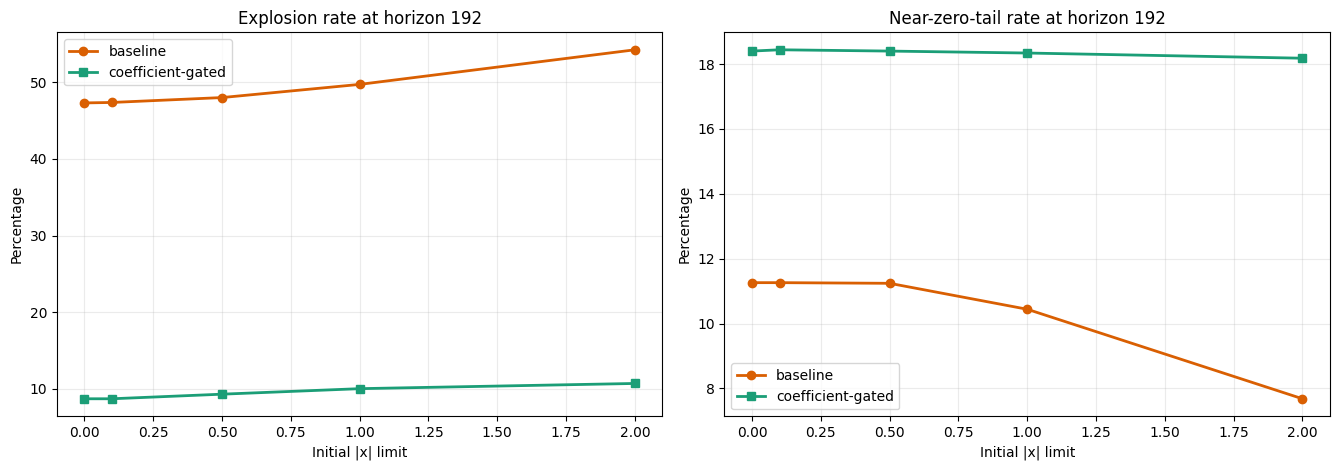

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
styles = {"baseline": ("#d95f02", "o"), "coefficient-gated": ("#1b9e77", "s")}

for variant, group in reference_summary.groupby("variant"):
    group = group.sort_values("input_abs_limit")
    color, marker = styles[variant]
    axes[0].plot(
        group["input_abs_limit"],
        100.0 * group["explosion_rate"],
        color=color,
        marker=marker,
        linewidth=2,
        label=variant,
    )
    axes[1].plot(
        group["input_abs_limit"],
        100.0 * group["near_zero_rate"],
        color=color,
        marker=marker,
        linewidth=2,
        label=variant,
    )

axes[0].set(title="Explosion rate at horizon 192", xlabel="Initial |x| limit", ylabel="Percentage")
axes[1].set(title="Near-zero-tail rate at horizon 192", xlabel="Initial |x| limit", ylabel="Percentage")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()
fig.tight_layout()
plt.show()

**O que foi feito.** Os gráficos colocam lado a lado o benefício esperado — menos explosões — e o efeito adverso que precisa ser controlado — mais caudas próximas de zero.

## 5. Comparação pareada e resultado por número de lags

Além das taxas marginais, contamos em quantos pares a intervenção impediu ou introduziu uma explosão. Depois estratificamos novamente por quantidade de folhas `LAG` para verificar onde ocorreu a redução.

,input_abs_limit,prevented_explosions,introduced_explosions,both_exploded,neither_exploded
0,0.0,1938,6,428,2628
1,0.1,1941,6,428,2625
2,0.5,1942,5,459,2594
3,1.0,1990,3,497,2510
4,2.0,2180,1,533,2286


,variant,lag_count,evaluated_mechanisms,explosions,explosion_rate,near_zero_rate
0,baseline,1,1848,71,0.038420,0.102814
1,baseline,2,1441,983,0.682165,0.104788
2,baseline,3,1017,774,0.761062,0.118977
3,baseline,4,488,378,0.774590,0.145492
4,baseline,5,160,126,0.787500,0.137500
5,baseline,6,40,29,0.725000,0.175000
6,baseline,7,6,5,0.833333,0.166667
7,coefficient-gated,1,1848,0,0.000000,0.136364
8,coefficient-gated,2,1441,83,0.057599,0.197779
9,coefficient-gated,3,1017,161,0.158309,0.203540


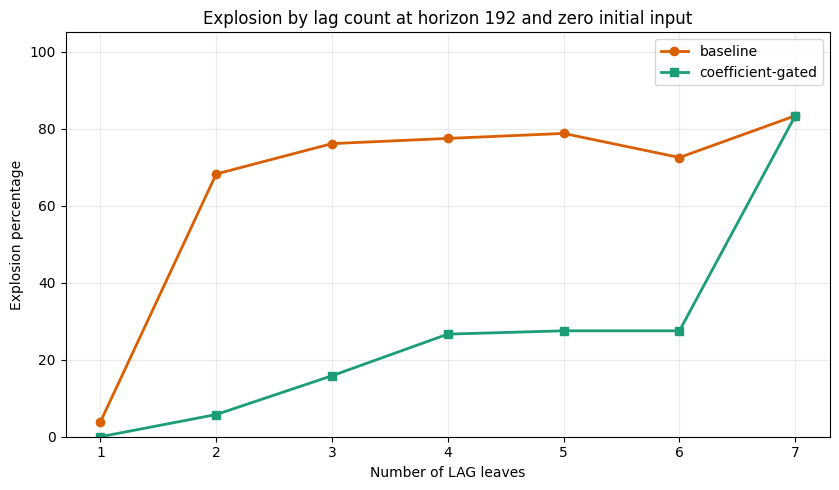

In [6]:
reference_outcomes = outcomes[outcomes["horizon"].eq(REFERENCE_HORIZON)]
paired_explosions = reference_outcomes.pivot(
    index=["sample_index", "input_abs_limit"],
    columns="variant",
    values="exploded",
).reset_index()

paired_transition_rows = []
for input_abs_limit, group in paired_explosions.groupby("input_abs_limit"):
    baseline = group["baseline"].astype(bool)
    gated = group["coefficient-gated"].astype(bool)
    paired_transition_rows.append({
        "input_abs_limit": input_abs_limit,
        "prevented_explosions": int((baseline & ~gated).sum()),
        "introduced_explosions": int((~baseline & gated).sum()),
        "both_exploded": int((baseline & gated).sum()),
        "neither_exploded": int((~baseline & ~gated).sum()),
    })
paired_transitions = pd.DataFrame(paired_transition_rows)
display(paired_transitions)

zero_initial_lag_summary = reference_outcomes[
    reference_outcomes["input_abs_limit"].eq(0.0)
].groupby(["variant", "lag_count"]).agg(
    evaluated_mechanisms=("sample_index", "size"),
    explosions=("exploded", "sum"),
    explosion_rate=("exploded", "mean"),
    near_zero_rate=("near_zero", "mean"),
).reset_index()
display(zero_initial_lag_summary)

fig, axis = plt.subplots(figsize=(8.5, 5))
for variant, group in zero_initial_lag_summary.groupby("variant"):
    group = group.sort_values("lag_count")
    color, marker = styles[variant]
    axis.plot(
        group["lag_count"],
        100.0 * group["explosion_rate"],
        color=color,
        marker=marker,
        linewidth=2,
        label=variant,
    )
axis.set(
    title="Explosion by lag count at horizon 192 and zero initial input",
    xlabel="Number of LAG leaves",
    ylabel="Explosion percentage",
    ylim=(0, 105),
)
axis.grid(alpha=0.25)
axis.legend()
fig.tight_layout()
plt.show()

**O que foi feito.** A comparação pareada distingue explosões realmente removidas de casos novos introduzidos pelos coeficientes. A estratificação por lag mostra se a estratégia atua justamente nas árvores identificadas como mais problemáticas.

## 6. Trade-off de velocidade

O tempo completo é apresentado junto com o número de passos realmente avaliados. A variante mais estável tende a executar mais passos antes de terminar, portanto comparar apenas trajetórias por segundo poderia penalizá-la por realizar mais trabalho útil.

,variant,sampling_seconds,sampled_mechanisms_per_second,simulation_seconds,attempted_trajectories,attempted_trajectories_per_second,evaluated_steps,evaluated_steps_per_second,full_384_step_successes,full_384_step_success_rate,sampling_time_relative_to_baseline,simulation_time_relative_to_baseline
0,baseline,2.103455,2377.041808,31.674592,25000,789.276159,5336248,168470.933024,11727,0.46908,1.000000,1.000000
1,coefficient-gated,2.473493,2021.432766,70.614204,25000,354.036418,8832851,125086.037222,21806,0.87224,1.175919,2.229364


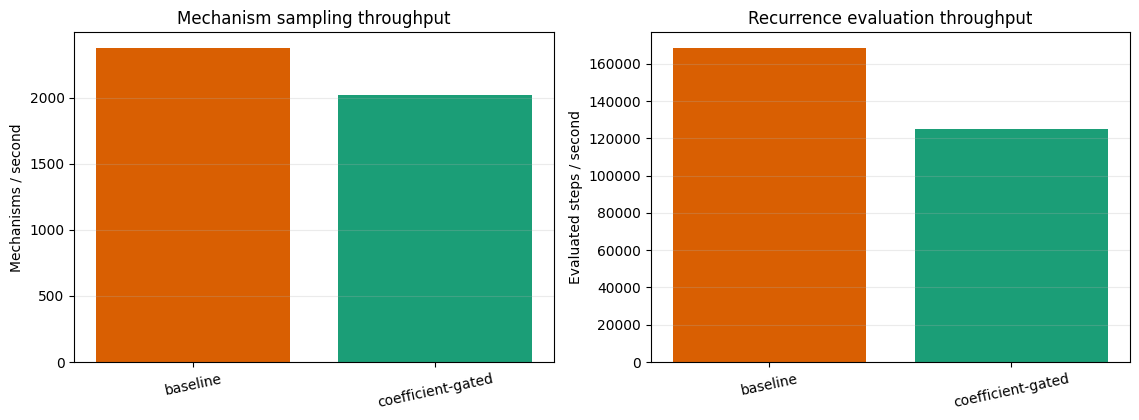

In [7]:
performance_comparison = generation_performance.set_index("variant").copy()
baseline_sampling = performance_comparison.loc["baseline", "sampling_seconds"]
baseline_simulation = performance_comparison.loc["baseline", "simulation_seconds"]
performance_comparison["sampling_time_relative_to_baseline"] = (
    performance_comparison["sampling_seconds"] / baseline_sampling
)
performance_comparison["simulation_time_relative_to_baseline"] = (
    performance_comparison["simulation_seconds"] / baseline_simulation
)
display(performance_comparison.reset_index())

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
axes[0].bar(
    performance_comparison.index,
    performance_comparison["sampled_mechanisms_per_second"],
    color=[styles[name][0] for name in performance_comparison.index],
)
axes[0].set(title="Mechanism sampling throughput", ylabel="Mechanisms / second")
axes[1].bar(
    performance_comparison.index,
    performance_comparison["evaluated_steps_per_second"],
    color=[styles[name][0] for name in performance_comparison.index],
)
axes[1].set(title="Recurrence evaluation throughput", ylabel="Evaluated steps / second")
for axis in axes:
    axis.tick_params(axis="x", rotation=12)
    axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

**O que foi feito.** A célula compara throughput e tempo relativo. Esses números descrevem esta execução e este hardware; a comparação final do projeto repetirá o benchmark para produzir intervalos de tempo.

## 7. Conclusão

Coefficient gating testa diretamente a hipótese levantada pelo Notebook 00: retirar o ganho unitário implícito de cada lag deve reduzir explosões. O resultado deve ser aceito como uma melhoria parcial somente se a redução não for obtida à custa de um aumento excessivo das caudas próximas de zero. Explosões remanescentes são esperadas porque vários coeficientes ainda podem produzir ganho agregado acima de um e porque produtos de variáveis defasadas continuam não lineares e não limitados.

## 8. Registro completo do experimento

A célula seguinte concentra pergunta, hipótese, configuração, proveniência, sementes, métricas, resumo científico, limitações e comando de reprodução.

In [8]:
def git_output(*arguments: str) -> str | None:
    try:
        return subprocess.check_output(
            ["git", *arguments],
            cwd=PROJECT_ROOT,
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip()
    except (subprocess.CalledProcessError, FileNotFoundError):
        return None


def json_records(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient="records"))


package_versions = {
    name: importlib.metadata.version(name)
    for name in ["numpy", "pandas", "matplotlib"]
}
reference_indexed = reference_summary.set_index(["variant", "input_abs_limit"])
baseline_zero = reference_indexed.loc[("baseline", 0.0)]
gated_zero = reference_indexed.loc[("coefficient-gated", 0.0)]
explosion_reduction_points = 100.0 * (
    baseline_zero["explosion_rate"] - gated_zero["explosion_rate"]
)
near_zero_increase_points = 100.0 * (
    gated_zero["near_zero_rate"] - baseline_zero["near_zero_rate"]
)

experiment_record = {
    "experiment_id": "abstract_syntax_tree_stability_mitigation_002_coefficient_gated_lags",
    "status": "executed",
    "research_question": (
        "Does adding one explicit sampled coefficient to every Lag leaf reduce recurrent-AST explosions, "
        "and what near-zero and runtime trade-offs does it introduce?"
    ),
    "hypothesis": (
        "Coefficient-gated lags substantially reduce explosions by removing implicit unit lag gains, "
        "but can increase near-zero tails because all temporal paths are attenuated."
    ),
    "configuration": configuration,
    "seed_policy": {
        "mechanism_seed": "derive_sample_seed(ROOT_SEED, sample_index)",
        "gate_coefficients": "continue the same per-mechanism RNG after sampling the unchanged base structure and bindings",
        "paired_trajectory_seed": "SeedSequence([ROOT_SEED, sample_index, 991])",
        "same_initial_values_and_innovations_between_variants": True,
        "same_trajectory_prefixes_across_horizons": True,
        "external_global_rng_used": False,
    },
    "provenance": {
        "implementation": [
            "src/tsfmxai/generators/random_expression.py",
            "src/tsfmxai/generators/trajectory.py",
            "src/tsfmxai/representations/expression.py",
        ],
        "baseline_notebook": "experiments/abstract_syntax_tree/4_large_scale_stability_and_equivalence.ipynb",
        "evidence_notebook": "experiments/abstract_syntax_tree/stability_mitigation/00_lag_count_explosion_evidence.ipynb",
        "project_head": git_output("rev-parse", "HEAD"),
        "python": sys.version,
        "platform": platform.platform(),
        "packages": package_versions,
    },
    "metrics": {
        "outcomes_by_variant_horizon_and_initial_bound": json_records(outcome_summary),
        "paired_transitions_at_horizon_192": json_records(paired_transitions),
        "zero_initial_outcomes_by_lag_count": json_records(zero_initial_lag_summary),
        "generation_performance": json_records(generation_performance),
        "zero_initial_explosion_reduction_percentage_points": explosion_reduction_points,
        "zero_initial_near_zero_increase_percentage_points": near_zero_increase_points,
    },
    "scientific_summary": (
        f"At horizon {REFERENCE_HORIZON} with zero initial input, coefficient gating reduced explosion frequency "
        f"from {baseline_zero['explosion_rate']:.2%} to {gated_zero['explosion_rate']:.2%} "
        f"(-{explosion_reduction_points:.2f} percentage points). Near-zero-tail frequency increased from "
        f"{baseline_zero['near_zero_rate']:.2%} to {gated_zero['near_zero_rate']:.2%} "
        f"(+{near_zero_increase_points:.2f} percentage points). The method therefore removes most explosions "
        "but does not dominate the baseline on both primary outcome metrics."
    ),
    "limitations": [
        "The intervention adds one operator and one parameter per Lag node, increasing expression size.",
        "Independent gate coefficients do not constrain their aggregate autoregressive gain.",
        "Products of lagged values remain unbounded nonlinear terms.",
        "Runtime values come from one complete execution; repeated timing belongs in the final trade-off benchmark.",
        "Near-zero tails are a finite-window diagnostic rather than proof of asymptotic convergence.",
    ],
    "reproduction_command": (
        r".\.venv\Scripts\python.exe -m jupyter nbconvert --to notebook --execute "
        r"experiments\abstract_syntax_tree\stability_mitigation\02_coefficient_gated_lags.ipynb "
        r"--inplace --ExecutePreprocessor.timeout=2400"
    ),
}

print(json.dumps(experiment_record, indent=2, ensure_ascii=False))

{
  "experiment_id": "abstract_syntax_tree_stability_mitigation_002_coefficient_gated_lags",
  "status": "executed",
  "research_question": "Does adding one explicit sampled coefficient to every Lag leaf reduce recurrent-AST explosions, and what near-zero and runtime trade-offs does it introduce?",
  "hypothesis": "Coefficient-gated lags substantially reduce explosions by removing implicit unit lag gains, but can increase near-zero tails because all temporal paths are attenuated.",
  "configuration": {
    "root_seed": 20261001,
    "sample_count_per_variant": 5000,
    "horizons": [
      96,
      192,
      384
    ],
    "reference_horizon": 192,
    "innovation_std": 0.05,
    "input_absolute_limits": [
      0.0,
      0.1,
      0.5,
      1.0,
      2.0
    ],
    "explosion_limit": 100.0,
    "near_zero_radius": 0.15000000000000002,
    "near_zero_tail_steps": 24,
    "baseline_tree_config": {
      "minimum_operators": 1,
      "maximum_operators": 6,
      "num_series": 1,
 

**Interpretação do registro.** O método realiza a intervenção proposta e quantifica benefício, custo e efeito adverso. Ele deve ser tratado como uma etapa do gerador estável, não como solução final, porque o aumento de caudas próximas de zero ainda precisa ser reduzido.